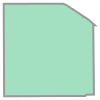

In [1]:
import shapely
from MobilityHubDataObjects import *
import pandas as pd
import geopandas as gpd
import folium
from pyproj import Transformer

#map_area = gpd.read_file("./data/raw/LA_City_Boundary/City_Boundary.shp").to_crs("EPSG:4326").loc[0, "geometry"]
map_area = gpd.read_file("./rawData/LA_Times_Neighborhood_Boundaries.geojson").loc[25, "geometry"]
map_area

In [2]:
fta_instance = FTAFacilityInventoryDataObject(
    "./rawData/2022 Facility Inventory.xlsx",
    column_filter={
        "Facility Type": [
            "Underground Fixed Guideway Station",
            "At-Grade Fixed Guideway Station",
            "Elevated Fixed Guideway Station",
        ]
    }
)
fta_instance.load_data(map_area)

In [3]:
afdc_instance = AFDCApiDataObject(constants.AFDC_DATA_URL, "./cache/afdc_cache.geojson", "./rawData/AFDC_API_KEY")

afdc_instance.load_data(map_area)

making api call


In [4]:
osm_instance = OSMDataObject("../data/cache/osmnx_cache", {"amenity": ["bicycle_parking"]})
osm_instance.load_data(map_area)

In [5]:
display_map = folium.Map(
    location=(34.10173, -118.2972),
    zoom_start=13
)
fta_instance.get_folium_plot().add_to(display_map)
afdc_instance.get_folium_plot().add_to(display_map)
osm_instance.get_folium_plot().add_to(display_map)
display_map